组合年化收益率（2W粒度）：70.95%


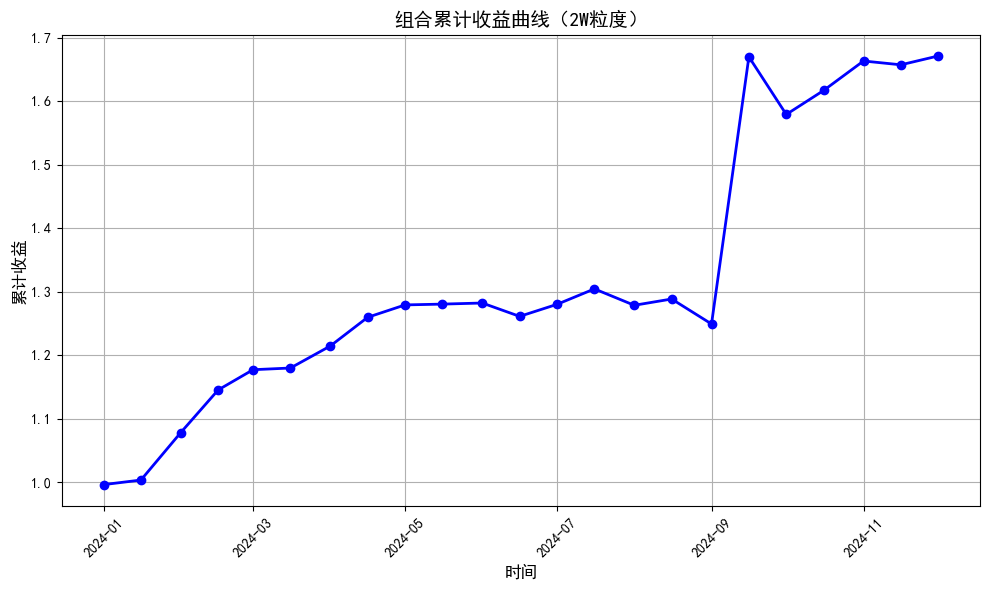

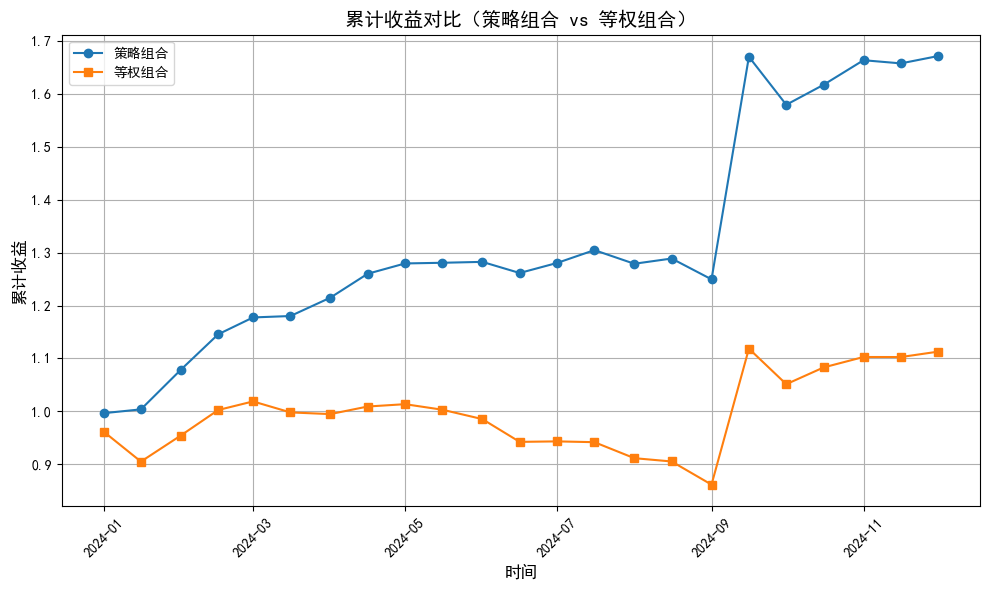

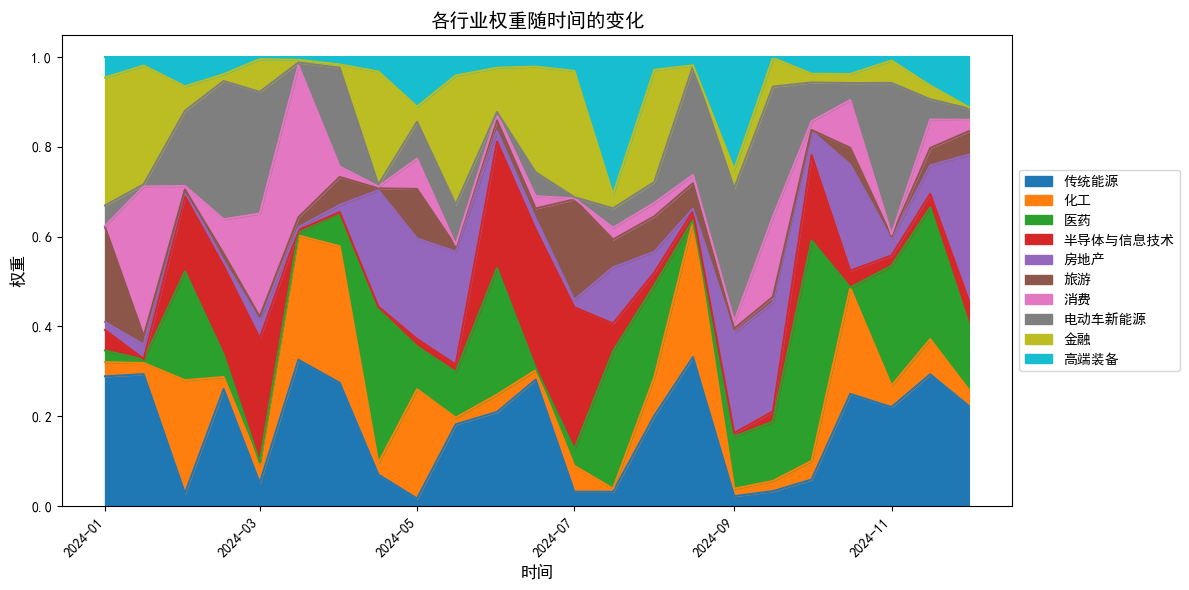

In [33]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    


def load_data(granularity='M'):
    file_path = f'C:\\Users\\wrz\\Desktop\\FYPProject\\factors_with_returns_{granularity}.csv'
    df = pd.read_csv(file_path, parse_dates=["period"])
    return df, file_path


def label_top(df, top_n=3):
    df = df.copy()
    df['rank'] = df.groupby('period')['return'].rank(ascending=False, method='first')
    df['label'] = 0
    df.loc[df['rank'] <= top_n, 'label'] = 1
    return df.drop(columns='rank')


def prepare_data(granularity='M'):
    df, file_path = load_data(granularity)
    df = label_top(df)
    X = df[['S_adjusted', 'M']]
    y = df['label']
    
    periods = sorted(df['period'].unique())
    split_point = int(len(periods) * 0.8)
    train_periods = periods[:split_point]
    test_periods = periods[split_point:]

    train_df = df[df['period'].isin(train_periods)]
    test_df = df[df['period'].isin(test_periods)]

    X_train = train_df[['S_adjusted', 'M']]
    y_train = train_df['label']
    X_test = test_df[['S_adjusted', 'M']]
    y_test = test_df['label']
    
    return df, X_train, y_train, X_test, y_test, file_path


def train_model(X_train, y_train):
    model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    return model

def predict_probabilities(df, model):
    df['prob'] = model.predict_proba(df[['S_adjusted', 'M']])[:, 1]
    return df


def normalize_weights(group):
    group = group.copy()
    group['weight'] = group['prob'] / group['prob'].sum()
    return group

# 7. 计算每期组合收益
def calculate_portfolio_returns(df):
    df['weighted_return'] = df['weight'] * df['return']
    portfolio_returns = df.groupby('period')['weighted_return'].sum().reset_index()
    portfolio_returns.rename(columns={'weighted_return': 'portfolio_return'}, inplace=True)
    return portfolio_returns


def calc_annual_return(returns, granularity='M', periods_per_year=None):
    if granularity == 'M':
        periods_per_year = 12
    elif granularity == 'W':
        periods_per_year = 52
    elif granularity == '2W':
        periods_per_year = 24
    elif granularity == 'D':
        periods_per_year = 252

    cumulative_return = (1 + returns).prod()
    n_periods = len(returns)
    return cumulative_return ** (periods_per_year / n_periods) - 1


def plot_cumulative_returns(portfolio_returns, title="组合累计收益曲线", xlabel="时间", ylabel="累计收益"):
    portfolio_returns['cumulative_return'] = (1 + portfolio_returns['portfolio_return']).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_returns['period'], portfolio_returns['cumulative_return'], marker='o', color='blue', linewidth=2)
    plt.xticks(rotation=45)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_strategy_vs_equal_weight(portfolio_returns, df):
    equal_weight_returns = df.groupby('period')['return'].mean().reset_index()
    equal_weight_returns.rename(columns={'return': 'equal_weight_return'}, inplace=True)

    portfolio_returns = portfolio_returns.merge(equal_weight_returns, on='period')
    portfolio_returns['cumulative_equal_weight'] = (1 + portfolio_returns['equal_weight_return']).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_returns['period'], portfolio_returns['cumulative_return'], label='策略组合', marker='o')
    plt.plot(portfolio_returns['period'], portfolio_returns['cumulative_equal_weight'], label='等权组合', marker='s')
    plt.xticks(rotation=45)
    plt.title("累计收益对比（策略组合 vs 等权组合）", fontsize=14)
    plt.xlabel("时间", fontsize=12)
    plt.ylabel("累计收益", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_weight_changes(df):
    pivot_weights = df.pivot(index='period', columns='industry', values='weight')
    pivot_weights.plot(kind='area', figsize=(12, 6), cmap='tab10')
    plt.title("各行业权重随时间的变化", fontsize=14)
    plt.xlabel("时间", fontsize=12)
    plt.ylabel("权重", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()

#主函数
def run_analysis(granularity='M'):
    df, X_train, y_train, X_test, y_test, file_path = prepare_data(granularity)
    model = train_model(X_train, y_train)
    df = predict_probabilities(df, model)
    df = df.groupby('period', group_keys=False).apply(normalize_weights).reset_index(drop=True)
    
    portfolio_returns = calculate_portfolio_returns(df)
    annual_return = calc_annual_return(portfolio_returns['portfolio_return'], granularity)
    print(f"组合年化收益率（{granularity}粒度）：{annual_return:.2%}")

    weights_output = df[['period', 'industry', 'weight']]
    output_weights_path = os.path.join(os.path.dirname(file_path), f'predicted_weights_{granularity}.csv')
    weights_output.to_csv(output_weights_path, index=False)

    returns_output_path = os.path.join(os.path.dirname(file_path), f'portfolio_returns_{granularity}.csv')
    portfolio_returns.to_csv(returns_output_path, index=False)

    plot_cumulative_returns(portfolio_returns, title=f"组合累计收益曲线（{granularity}粒度）")
    plot_strategy_vs_equal_weight(portfolio_returns, df)
    plot_weight_changes(df)

#调用
run_analysis(granularity='2W')


特征对模型预测的贡献度：
 - S_adjusted: 0.5074
 - M: 0.4926
Equal-weighted Annual Return (W): 2.16%
Strategy Annual Return (W): 63.71%


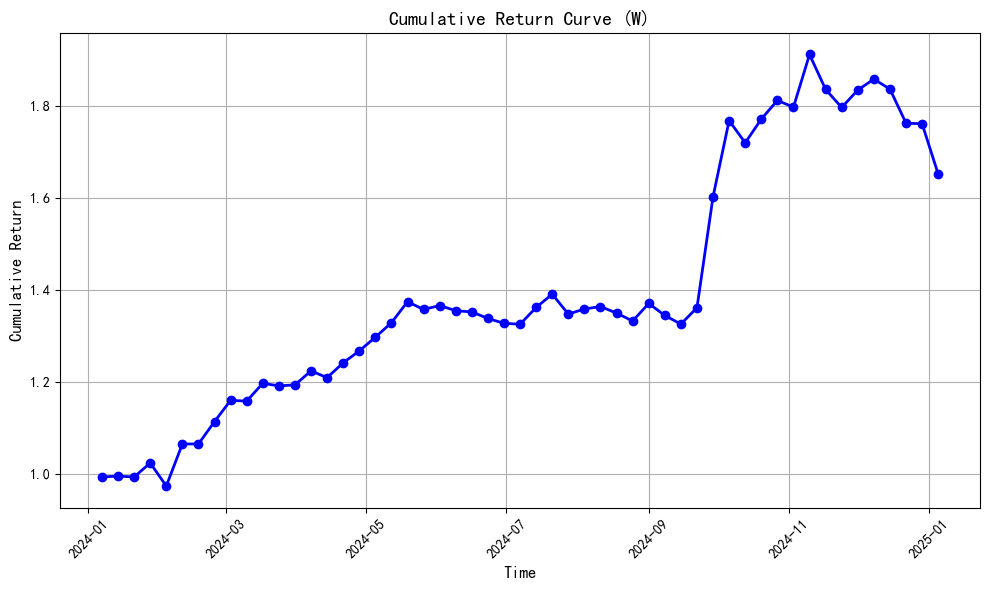

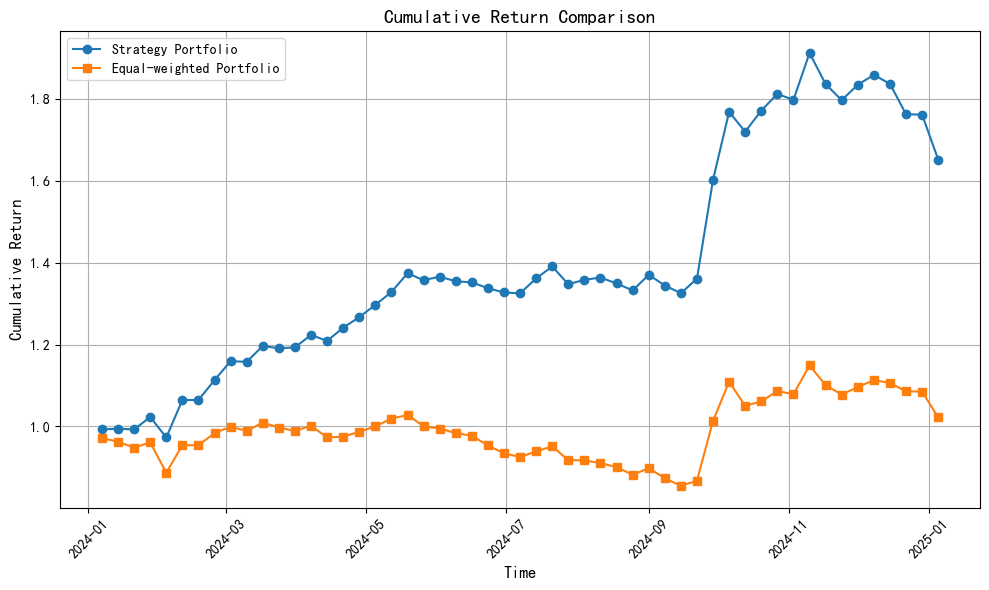

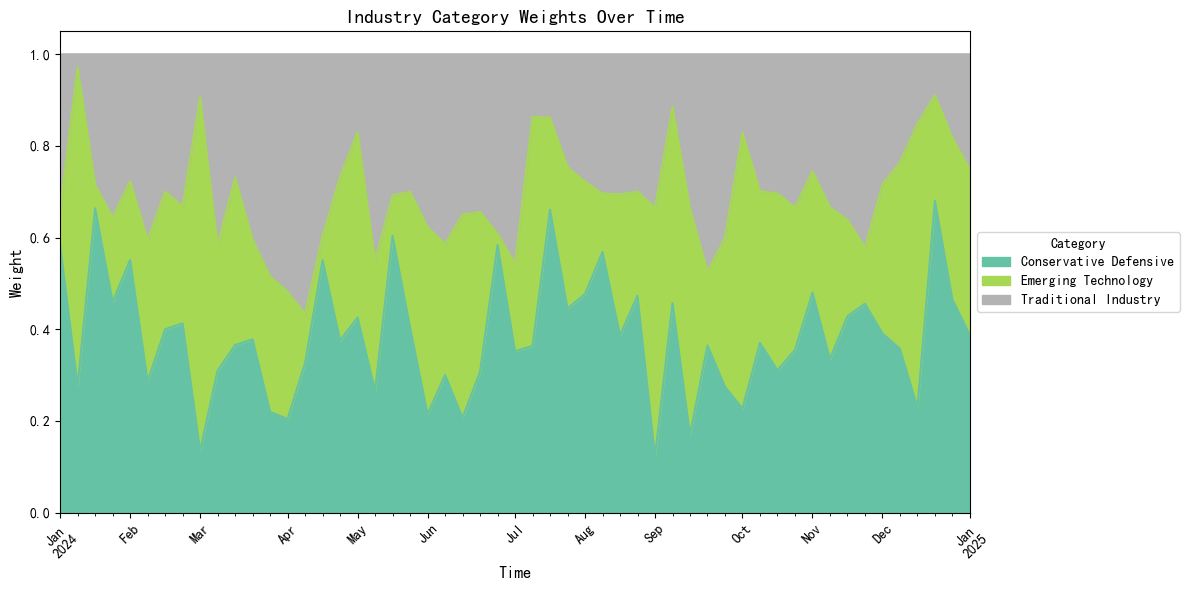

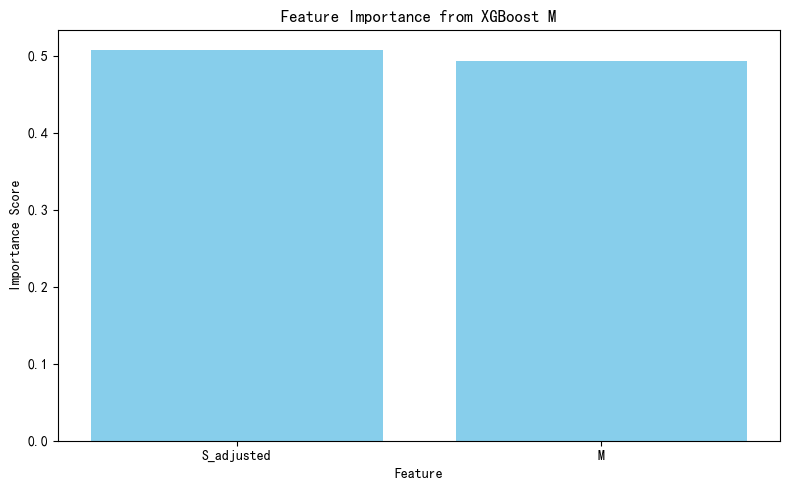

In [34]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    


def load_data(granularity='M'):
    file_path = f'C:\\Users\\wrz\\Desktop\\FYPProject\\factors_with_returns_{granularity}.csv'
    df = pd.read_csv(file_path, parse_dates=["period"])
    return df, file_path


def label_top(df, top_n=3):
    df = df.copy()
    df['rank'] = df.groupby('period')['return'].rank(ascending=False, method='first')
    df['label'] = 0
    df.loc[df['rank'] <= top_n, 'label'] = 1
    return df.drop(columns='rank')


def prepare_data(granularity='M'):
    df, file_path = load_data(granularity)
    df = label_top(df)
    X = df[['S_adjusted', 'M']]
    y = df['label']
    
    df['industry'] = df['industry'].replace({
        '化工': 'Chemicals',
        '传统能源': 'Traditional Energy',
        '房地产': 'Real Estate',
        '金融': 'Finance',
        '消费': 'Consumer',
        '旅游': 'Tourism',
        '医药': 'Healthcare',
        '电动车新能源': 'EV & New Energy',
        '高端装备': 'Advanced Equipment',
        '半导体与信息技术': 'Semiconductors & IT'
    })

    periods = sorted(df['period'].unique())
    split_point = int(len(periods) * 0.8)
    train_periods = periods[:split_point]
    test_periods = periods[split_point:]

    train_df = df[df['period'].isin(train_periods)]
    test_df = df[df['period'].isin(test_periods)]

    X_train = train_df[['S_adjusted', 'M']]
    y_train = train_df['label']
    X_test = test_df[['S_adjusted', 'M']]
    y_test = test_df['label']
    
    return df, X_train, y_train, X_test, y_test, file_path


def train_model(X_train, y_train):
    model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)

    feature_names = X_train.columns
    importances = model.feature_importances_

    print("特征对模型预测的贡献度：")
    for name, importance in zip(feature_names, importances):
        print(f" - {name}: {importance:.4f}")

    return model



def predict_probabilities(df, model):
    df['prob'] = model.predict_proba(df[['S_adjusted', 'M']])[:, 1]
    return df


def normalize_weights(group):
    group = group.copy()
    group['weight'] = group['prob'] / group['prob'].sum()
    return group


def calculate_portfolio_returns(df):
    df['weighted_return'] = df['weight'] * df['return']
    portfolio_returns = df.groupby('period')['weighted_return'].sum().reset_index()
    portfolio_returns.rename(columns={'weighted_return': 'portfolio_return'}, inplace=True)
    return portfolio_returns


def calc_annual_return(returns, granularity='M'):
    if granularity == 'M':
        periods_per_year = 12
    elif granularity == 'W':
        periods_per_year = 52
    elif granularity == '2W':
        periods_per_year = 24
    elif granularity == 'D':
        periods_per_year = 252
    else:
        periods_per_year = 12

    cumulative_return = (1 + returns).prod()
    n_periods = len(returns)
    return cumulative_return ** (periods_per_year / n_periods) - 1


def plot_cumulative_returns(portfolio_returns, title="Cumulative Return Curve", xlabel="Time", ylabel="Cumulative Return"):
    portfolio_returns['cumulative_return'] = (1 + portfolio_returns['portfolio_return']).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_returns['period'], portfolio_returns['cumulative_return'], marker='o', color='blue', linewidth=2)
    plt.xticks(rotation=45)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_strategy_vs_equal_weight(portfolio_returns, df):
    equal_weight_returns = df.groupby('period')['return'].mean().reset_index()
    equal_weight_returns.rename(columns={'return': 'equal_weight_return'}, inplace=True)

    portfolio_returns = portfolio_returns.merge(equal_weight_returns, on='period')
    portfolio_returns['cumulative_equal_weight'] = (1 + portfolio_returns['equal_weight_return']).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_returns['period'], portfolio_returns['cumulative_return'], label='Strategy Portfolio', marker='o')
    plt.plot(portfolio_returns['period'], portfolio_returns['cumulative_equal_weight'], label='Equal-weighted Portfolio', marker='s')
    plt.xticks(rotation=45)
    plt.title("Cumulative Return Comparison", fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Cumulative Return", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_weight_changes(df):
    df = df.copy()

    category_mapping = {
        'Chemicals': 'Traditional Industry',
        'Traditional Energy': 'Traditional Industry',
        'Real Estate': 'Traditional Industry',
        'Finance': 'Conservative Defensive',
        'Tourism': 'Conservative Defensive',
        'Healthcare': 'Conservative Defensive',
        'Consumer': 'Conservative Defensive',
        'EV & New Energy': 'Emerging Technology',
        'Advanced Equipment': 'Emerging Technology',
        'Semiconductors & IT': 'Emerging Technology'
    }

    df['category'] = df['industry'].map(category_mapping)
    grouped_weights = df.groupby(['period', 'category'])['weight'].sum().unstack()
    grouped_weights.plot(kind='area', figsize=(12, 6), cmap='Set2')
    plt.title("Industry Category Weights Over Time", fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Weight", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Category', loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1]
    plt.figure(figsize=(8, 5))
    plt.bar(range(len(importance)), importance[sorted_idx], color='skyblue')
    plt.xticks(range(len(importance)), [feature_names[i] for i in sorted_idx])
    plt.title("Feature Importance from XGBoost M")
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()

# 主函数
def run_analysis(granularity='M'):
    df, X_train, y_train, X_test, y_test, file_path = prepare_data(granularity)
    model = train_model(X_train, y_train)
    df = predict_probabilities(df, model)
    df = df.groupby('period', group_keys=False).apply(normalize_weights).reset_index(drop=True)

    equal_weight_returns = df.groupby('period')['return'].mean().reset_index()
    equal_weight_annual_return = calc_annual_return(equal_weight_returns['return'], granularity)
    print(f"Equal-weighted Annual Return ({granularity}): {equal_weight_annual_return:.2%}")

    portfolio_returns = calculate_portfolio_returns(df)
    annual_return = calc_annual_return(portfolio_returns['portfolio_return'], granularity)
    print(f"Strategy Annual Return ({granularity}): {annual_return:.2%}")

    plot_cumulative_returns(portfolio_returns, title=f"Cumulative Return Curve ({granularity})")
    plot_strategy_vs_equal_weight(portfolio_returns, df)
    plot_weight_changes(df)
    plot_feature_importance(model, feature_names=['S_adjusted', 'M'])
    
    weights_output = df[['period', 'industry', 'weight']]
    output_weights_path = os.path.join(os.path.dirname(file_path), f'predicted_weights_{granularity}.csv')
    weights_output.to_csv(output_weights_path, index=False)

    returns_output_path = os.path.join(os.path.dirname(file_path), f'portfolio_returns_{granularity}.csv')
    portfolio_returns.to_csv(returns_output_path, index=False)

# 调节粒度
run_analysis(granularity='W')
